## Last.fm Asia Social Network Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

## 2. Load Datasets

In [2]:
edges_path = "/content/lastfm_asia_edges.csv"
features_path = "/content/lastfm_asia_features.json"
target_path = "/content/lastfm_asia_target.csv"

edges = pd.read_csv(edges_path)
targets = pd.read_csv(target_path)

with open(features_path, "r", encoding="utf-8") as f:
    features = json.load(f)

print("Edges shape:", edges.shape)
print("Target shape:", targets.shape)
print("Edge columns:", edges.columns.tolist())
print("Target columns:", targets.columns.tolist())

Edges shape: (27806, 2)
Target shape: (7624, 2)
Edge columns: ['node_1', 'node_2']
Target columns: ['id', 'target']


## 3. Data Quality checks


In [3]:
print("\nMissing values in edges:")
print(edges.isna().sum())

print("\nDuplicate edges:", edges.duplicated().sum())
print("Self-loops:", (edges["node_1"] == edges["node_2"]).sum())
print("Duplicate target IDs:", targets["id"].duplicated().sum())
print("Missing target values:", targets["target"].isna().sum())


Missing values in edges:
node_1    0
node_2    0
dtype: int64

Duplicate edges: 0
Self-loops: 0
Duplicate target IDs: 0
Missing target values: 0


## 4. Remove self-loops and duplicate edges

In [4]:
edges = edges[edges["node_1"] != edges["node_2"]].drop_duplicates()

## 5. Network Construction and Basic Statistics

In [5]:
G = nx.from_pandas_edgelist(
    edges,
    source="node_1",
    target="node_2",
    create_using=nx.Graph()
)

print("\nNumber of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is directed:", G.is_directed())
print("Is connected:", nx.is_connected(G))
print("Density:", nx.density(G))

components = sorted(
    [len(c) for c in nx.connected_components(G)],
    reverse=True
)
print("Number of connected components:", len(components))
print("Largest component size:", components[0])


Number of nodes: 7624
Number of edges: 27806
Is directed: False
Is connected: True
Density: 0.0009568849118596328
Number of connected components: 1
Largest component size: 7624


## 6. Degree Distribution Analysis


Degree summary:
count    7624.000000
mean        7.294334
std        11.499873
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max       216.000000
dtype: float64


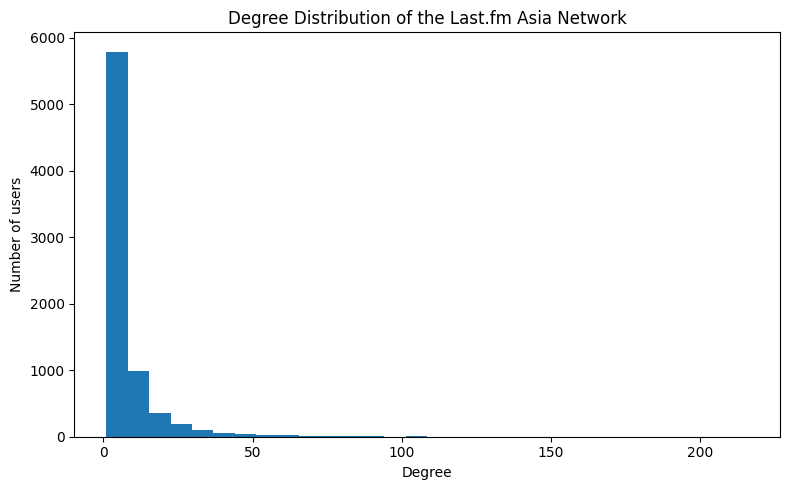

In [6]:
degrees = np.array([degree for _, degree in G.degree()])
degree_summary = pd.Series(degrees).describe()
print("\nDegree summary:")
print(degree_summary)

plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=30)
plt.title("Degree Distribution of the Last.fm Asia Network")
plt.xlabel("Degree")
plt.ylabel("Number of users")
plt.tight_layout()
plt.show()

## 7. Log-log degree frequency plot

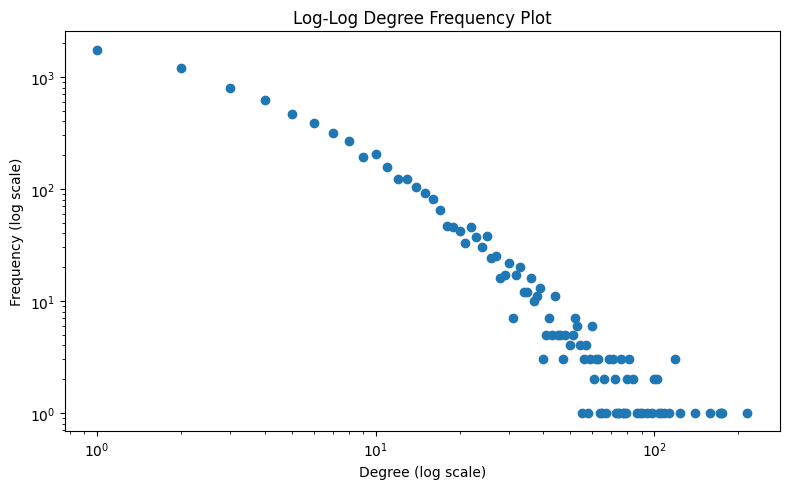

In [7]:
degree_counts = Counter(degrees)
x = sorted(degree_counts.keys())
y = [degree_counts[k] for k in x]

plt.figure(figsize=(8, 5))
plt.loglog(x, y, marker="o", linestyle="none")
plt.title("Log-Log Degree Frequency Plot")
plt.xlabel("Degree (log scale)")
plt.ylabel("Frequency (log scale)")
plt.tight_layout()
plt.show()

## 8. Connected Component Analysis


Component sizes: [7624]


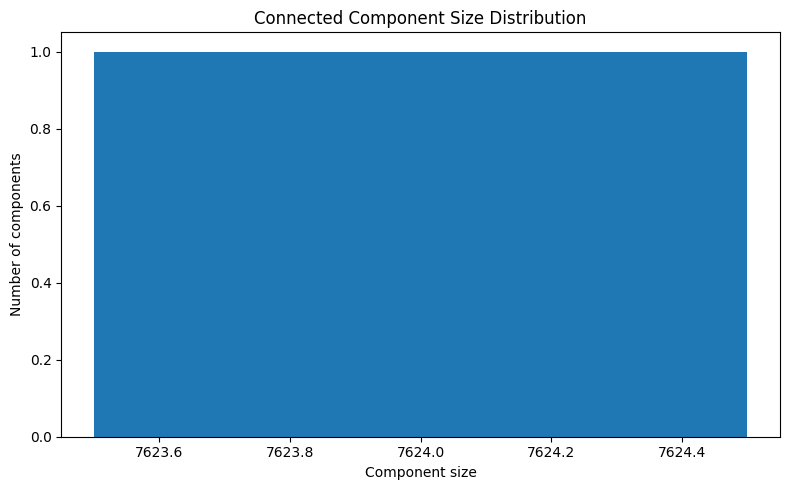

In [8]:
component_sizes = [len(c) for c in nx.connected_components(G)]
print("\nComponent sizes:", sorted(component_sizes, reverse=True)[:10])

plt.figure(figsize=(8, 5))
plt.hist(component_sizes, bins=min(20, len(set(component_sizes))))
plt.title("Connected Component Size Distribution")
plt.xlabel("Component size")
plt.ylabel("Number of components")
plt.tight_layout()
plt.show()

## 9. Shortest path



In [9]:
largest_nodes = max(nx.connected_components(G), key=len)
GC = G.subgraph(largest_nodes).copy()

print("\nAverage shortest path length:", nx.average_shortest_path_length(GC))
print("Diameter:", nx.diameter(GC))
print("Radius:", nx.radius(GC))


Average shortest path length: 5.232237268915701
Diameter: 15
Radius: 8


## 10. Distance distribution from a sample of nodes for large networks

In [10]:
sample_nodes = list(GC.nodes())[:min(100, GC.number_of_nodes())]
sample_distances = []

for node in sample_nodes:
    lengths = nx.single_source_shortest_path_length(GC, node)
    sample_distances.extend(lengths.values())

print("Sampled mean shortest-path distance:",
      np.mean(sample_distances))

Sampled mean shortest-path distance: 4.9704328436516265


## 11. Clustering coefficient and density




In [11]:
print("\nAverage clustering coefficient:",
      nx.average_clustering(G))
print("Global transitivity:", nx.transitivity(G))
print("Network density:", nx.density(G))


Average clustering coefficient: 0.219418424327086
Global transitivity: 0.178622548153384
Network density: 0.0009568849118596328


## 12. Calculate degree, closeness, betweenness, and eigenvector centrality

In [12]:
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

## 13. betweenness & eigenvector

In [13]:
betweenness_centrality = nx.betweenness_centrality(
    G, k=min(500, G.number_of_nodes()), seed=42
)

eigenvector_centrality = nx.eigenvector_centrality(
    G, max_iter=1000
)

def top_nodes(score_dict, n=10):
    return sorted(score_dict.items(),
                  key=lambda item: item[1],
                  reverse=True)[:n]

print("\nTop degree-centrality users:")
print(top_nodes(degree_centrality))

print("\nTop closeness-centrality users:")
print(top_nodes(closeness_centrality))

print("\nTop betweenness-centrality users:")
print(top_nodes(betweenness_centrality))

print("\nTop eigenvector-centrality users:")
print(top_nodes(eigenvector_centrality))


Top degree-centrality users:
[(7237, 0.02833530106257379), (3530, 0.022956841138659322), (4785, 0.022825659189295553), (524, 0.022563295290568018), (3450, 0.02085792994883904), (2510, 0.018365472910927456), (3597, 0.016266561721107176), (2854, 0.015610651974288339), (6101, 0.015610651974288339), (5127, 0.015610651974288339)]

Top closeness-centrality users:
[(7199, 0.29071009076348103), (7237, 0.28567681007345225), (4356, 0.28160325083117843), (2854, 0.2803501158471553), (5454, 0.27982526980397915), (5127, 0.27464332036316474), (3544, 0.2734708520179372), (6101, 0.27329437493277886), (3450, 0.272172236503856), (4900, 0.26914521766761995)]

Top betweenness-centrality users:
[(7237, 0.09216630310578297), (7199, 0.08581730896327669), (2854, 0.07883581344788153), (4356, 0.06213971393456214), (6101, 0.047993328588650803), (5454, 0.0411146786637361), (3530, 0.03629101827774296), (5127, 0.036188488738796654), (4785, 0.03478422349342937), (4338, 0.034743668732282997)]

Top eigenvector-central

## 14. Compare the observed network with Erdős–Rényi, Barabási–Albert, and Watts–Strogatz networks

In [14]:
n = G.number_of_nodes()
m = G.number_of_edges()
average_degree = 2 * m / n
p = average_degree / (n - 1)

ER = nx.gnp_random_graph(n, p, seed=42)

## 15. BA

In [15]:
ba_m = max(1, int(round(average_degree / 2)))
BA = nx.barabasi_albert_graph(n, ba_m, seed=42)

## 16. ER,BA and WS

In [16]:
ws_k = max(2, int(round(average_degree)))
if ws_k % 2 != 0:
    ws_k -= 1
WS = nx.watts_strogatz_graph(n, ws_k, 0.1, seed=42)

def graph_statistics(H):
    largest = H.subgraph(max(nx.connected_components(H), key=len)).copy()
    return {
        "nodes": H.number_of_nodes(),
        "edges": H.number_of_edges(),
        "density": nx.density(H),
        "components": nx.number_connected_components(H),
        "largest_component": largest.number_of_nodes(),
        "average_clustering": nx.average_clustering(H),
        "average_path_length_largest_component":
            nx.average_shortest_path_length(largest),
        "diameter_largest_component": nx.diameter(largest)
    }

comparison = pd.DataFrame({
    "Last.fm Asia": graph_statistics(G),
    "ER": graph_statistics(ER),
    "BA": graph_statistics(BA),
    "WS": graph_statistics(WS)
}).T

print("\nModel comparison:")
display(comparison)


Model comparison:


,nodes,edges,density,components,largest_component,average_clustering,average_path_length_largest_component,diameter_largest_component
Last.fm Asia,7624.0,27806.0,0.000957,1.0,7624.0,0.219418,5.232237,15.0
ER,7624.0,27457.0,0.000945,9.0,7616.0,0.000705,4.750125,9.0
BA,7624.0,30480.0,0.001049,1.0,7624.0,0.007558,3.828201,6.0
WS,7624.0,22872.0,0.000787,1.0,7624.0,0.442309,8.326708,15.0


In [17]:
degree_df = pd.DataFrame({
    "id": list(dict(G.degree()).keys()),
    "degree": list(dict(G.degree()).values())
})

analysis_df = targets.merge(degree_df, on="id", how="inner")

print("\nTarget-label summary:")
print(analysis_df["target"].value_counts().sort_index())

label_summary = analysis_df.groupby("target")["degree"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).sort_values("mean", ascending=False)

print("\nDegree by target label:")
display(label_summary)


Target-label summary:
target
0     1098
1       54
2       73
3      515
4       16
5      391
6      655
7       82
8      468
9       58
10    1303
11     138
12      57
13      63
14     570
15     257
16     254
17    1572
Name: count, dtype: int64

Degree by target label:


,count,mean,median,std,min,max
target,,,,,,
15,257,12.303502,6.0,17.770711,1,172
8,468,9.760684,6.0,11.849448,1,81
0,1098,9.157559,4.0,15.534938,1,216
11,138,8.978261,5.0,9.890988,1,47
2,73,8.849315,5.0,10.514106,1,54
14,570,8.221053,4.0,13.091146,1,140
13,63,7.476190,4.0,7.084415,1,29
10,1303,7.066002,4.0,10.278694,1,119
17,1572,6.694656,3.0,10.871257,1,175


## 17. The relationship between network connectivity and target labels


Correlation between target and degree: -0.01899639900207475


<Figure size 1000x500 with 0 Axes>

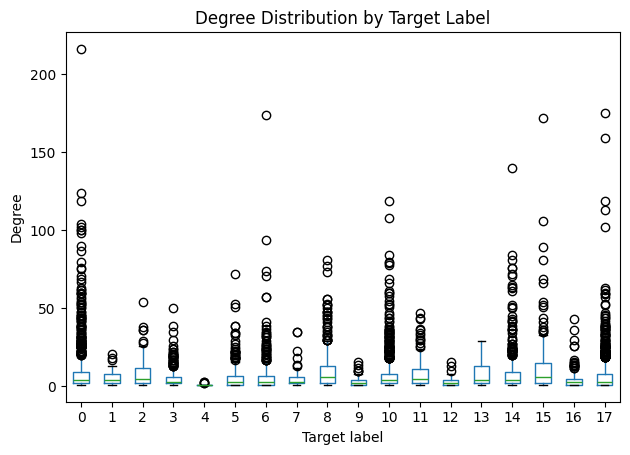

In [18]:
print("\nCorrelation between target and degree:",
      analysis_df["target"].corr(analysis_df["degree"]))

plt.figure(figsize=(10, 5))
analysis_df.boxplot(column="degree", by="target", grid=False)
plt.title("Degree Distribution by Target Label")
plt.suptitle("")
plt.xlabel("Target label")
plt.ylabel("Degree")
plt.tight_layout()
plt.show()